### MNIST DNN Project

In [2]:
#----------------------------------------------------------------#
#To install: pip install numpy
import numpy as np
#To install: pip install matplotlib
import matplotlib.pyplot as plt
#To install: pip install sklearn
import sklearn
#To install: pip install torchvision
import torchvision as tv
import torchvision.transforms as transforms
#To install: pip install torch (not GPU compatible)
import torch
import torch.nn as nn
#----------------------------------------------------------------#

In [3]:
# Below is the train/test data from MNIST.
#----------------------------------------------------------------#
train_data = tv.datasets.MNIST('./data', train=True, transform=transforms.ToTensor(), download=True)
test_data = tv.datasets.MNIST('./data', train=False, transform=transforms.ToTensor(), download=True)
#----------------------------------------------------------------#

# Print the shape of data and the shape of labels
"""
Tips:
- To get just the data from (train/test)_data, you will need to do (train/test)_data.data
- To get just the labels from (train/test)_data, you will need to do (train/test)_data.targets
- Then use .numpy() to convert the data into a numpy array, which you can then call .shape on
"""
print("Train Data Shape:", train_data.data.numpy().shape)
print("Train Labels Shape:", train_data.targets.numpy().shape)
print("Test Data Shape:", test_data.data.numpy().shape)
print("Test Labels Shape:", test_data.targets.numpy().shape)
#----------------------------------------------------------------#

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.13MB/s]

Train Data Shape: (60000, 28, 28)
Train Labels Shape: (60000,)
Test Data Shape: (10000, 28, 28)
Test Labels Shape: (10000,)


In [4]:
# Creates dataloaders from the MNIST dataset
batch_size = 30
#----------------------------------------------------------------#
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)
#----------------------------------------------------------------#

Quick Visualization

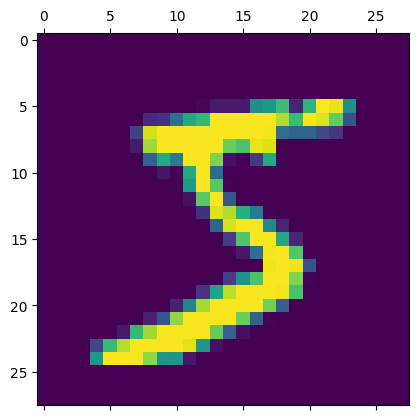

Associated Label: 5


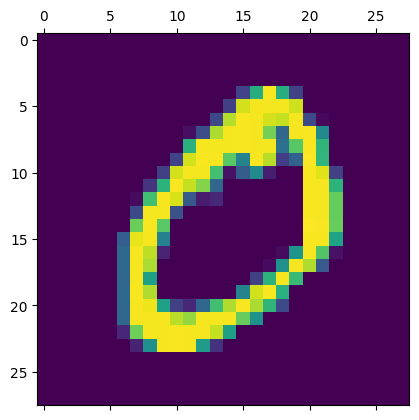

Associated Label: 0


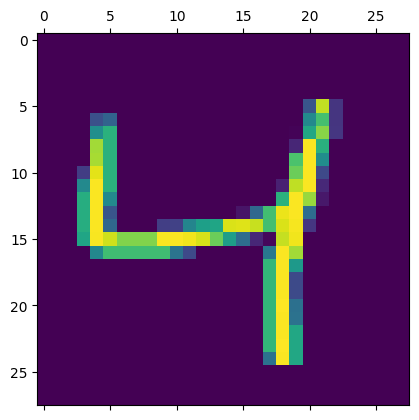

Associated Label: 4


In [5]:
# Visualizes num_to_viz digits and labels with plt.matshow and plt.show. Notice how reshape is used to get the data into proper format for visualization.
#----------------------------------------------------------------#
num_of_digits_to_viz = 3
for i in range(num_of_digits_to_viz):
    to_reshape = train_data.data.numpy()[i]
    plt.matshow(to_reshape.reshape(28, 28))
    plt.show()
    print(f"Associated Label: {train_data.targets.numpy()[i]}")
#----------------------------------------------------------------#

DNN Model

In [6]:
from math import sqrt

class MNIST_DNN(nn.Module):
    def __init__(self, train_data):
        super(MNIST_DNN, self).__init__()

        x = sqrt(sqrt(train_data.data.numpy().shape[1]*train_data.data.numpy().shape[2]/10))
        # Structure
        self.input_layer_size = train_data.data.numpy().shape[1]*train_data.data.numpy().shape[2]
        self.hidden_layer_A_size = int(train_data.data.numpy().shape[1]*train_data.data.numpy().shape[2] / x)
        self.hidden_layer_B_size = int(self.hidden_layer_A_size / x)
        self.hidden_layer_C_size = int(self.hidden_layer_B_size / x)
        self.output_layer_size = 10

        # Layers
        self.l1 = nn.Linear(self.input_layer_size, self.hidden_layer_A_size)
        self.l2 = nn.Linear(self.hidden_layer_A_size, self.hidden_layer_B_size)
        self.l3 = nn.Linear(self.hidden_layer_B_size, self.hidden_layer_C_size)
        self.l4 = nn.Linear(self.hidden_layer_C_size, self.output_layer_size)

        # Activations
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax()

    def forward(self, input):
        x = self.l1(input)
        x = self.sigmoid(x)
        x = self.l2(x)
        x = self.sigmoid(x)
        x = self.l3(x)
        x = self.sigmoid(x)
        x = self.l4(x)
        output = self.softmax(x)
        return output



Choose model here

In [9]:
model = MNIST_DNN(train_data)

In [16]:
loss_func = nn.CrossEntropyLoss() # Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Adaptive Optimizer

Training Loop

In [17]:
num_epochs = 10

## TODO: Implement the training loop as shown in the tutorial, but remove all calls to .to(device)

total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Origin shape: [N, 1, 28, 28]
        # Reshaped: [N, 784]
        images = images.reshape(-1, 28*28)

        # Forward pass
        outputs = model(images)
        loss = loss_func(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}')

Epoch [1/10], Step [100/2000], Loss: 1.9906
Epoch [1/10], Step [200/2000], Loss: 1.9564
Epoch [1/10], Step [300/2000], Loss: 2.0145
Epoch [1/10], Step [400/2000], Loss: 1.7975
Epoch [1/10], Step [500/2000], Loss: 1.7799
Epoch [1/10], Step [600/2000], Loss: 1.6948
Epoch [1/10], Step [700/2000], Loss: 1.9016
Epoch [1/10], Step [800/2000], Loss: 1.6917
Epoch [1/10], Step [900/2000], Loss: 1.8740
Epoch [1/10], Step [1000/2000], Loss: 1.8104
Epoch [1/10], Step [1100/2000], Loss: 1.7253
Epoch [1/10], Step [1200/2000], Loss: 1.7940
Epoch [1/10], Step [1300/2000], Loss: 1.7682
Epoch [1/10], Step [1400/2000], Loss: 1.7663
Epoch [1/10], Step [1500/2000], Loss: 1.7062
Epoch [1/10], Step [1600/2000], Loss: 1.6797
Epoch [1/10], Step [1700/2000], Loss: 1.6373
Epoch [1/10], Step [1800/2000], Loss: 1.7588
Epoch [1/10], Step [1900/2000], Loss: 1.8031
Epoch [1/10], Step [2000/2000], Loss: 1.6764
Epoch [2/10], Step [100/2000], Loss: 1.7472
Epoch [2/10], Step [200/2000], Loss: 1.6398
Epoch [2/10], Step [3

Testing Loop

In [18]:
#----------------------------------------------------------------#
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs.data, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network on the 10000 test images: {acc} %')
#----------------------------------------------------------------#

Accuracy of the network on the 10000 test images: 96.37 %


Save DNN

In [19]:
torch.save(model.state_dict(), "my_mnist_model.pth")

print("Model weights saved to my_mnist_model.pth")


Model weights saved to my_mnist_model.pth


In [20]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 67.1 MB/s eta 0:00:00


In [22]:
import onnx
class MNIST_DNN(nn.Module):
    def __init__(self, train_data_shape_28x28):
        super(MNIST_DNN, self).__init__()

        # We can't pass 'train_data' here, so we just need the shape
        # We know it's 28x28
        shape_x, shape_y = train_data_shape_28x28

        x = sqrt(sqrt(shape_x * shape_y / 10))
        # Structure
        self.input_layer_size = shape_x * shape_y
        self.hidden_layer_A_size = int(self.input_layer_size / x)
        self.hidden_layer_B_size = int(self.hidden_layer_A_size / x)
        self.hidden_layer_C_size = int(self.hidden_layer_B_size / x)
        self.output_layer_size = 10

        # Layers
        self.l1 = nn.Linear(self.input_layer_size, self.hidden_layer_A_size)
        self.l2 = nn.Linear(self.hidden_layer_A_size, self.hidden_layer_B_size)
        self.l3 = nn.Linear(self.hidden_layer_B_size, self.hidden_layer_C_size)
        self.l4 = nn.Linear(self.hidden_layer_C_size, self.output_layer_size)

        # Activations
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax()

    def forward(self, input):
        x = self.l1(input)
        x = self.sigmoid(x)
        x = self.l2(x)
        x = self.sigmoid(x)
        x = self.l3(x)
        x = self.sigmoid(x)
        x = self.l4(x)
        output = self.softmax(x)
        return output

# --- END OF CLASS DEFINITION ---

# 1. Instantiate your model structure
#    (We pass (28, 28) for the shape)
model_for_export = MNIST_DNN((28, 28))

# 2. Load your saved weights
model_for_export.load_state_dict(torch.load("my_mnist_model.pth"))

# 3. Set to evaluation mode (very important!)
model_for_export.eval()

# 4. === THIS IS THE KEY PART ===
# Because your model is a flat DNN (not a CNN),
# we must use a dummy input of shape [1, 784].
dummy_input = torch.randn(1, 784)

# 5. Export the model
torch.onnx.export(model_for_export,
                  dummy_input,
                  "my_mnist_model.onnx",
                  dynamo=False,
                  export_params=True,
                  opset_version=10,
                  do_constant_folding=True,
                  input_names = ['input'],
                  output_names = ['output'],
                  dynamic_axes={'input' : {0 : 'batch_size'},
                                'output' : {0 : 'batch_size'}})

print("Model has been converted to my_mnist_model.onnx")

/tmp/ipykernel_7011/999051723.py:57: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_for_export,
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1787: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return forward_call(*args, **kwargs)


Model has been converted to my_mnist_model.onnx
